# Working with FOORT

This notebook provides a concise example of how to visualise FOORT output, while making use of the provided functions. The example covers the Kerr and Johannsen black holes, as presented in the Demonstrations section of the FOORT paper.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pyFOORT as pf
import PhotonRingInterferometry as PRI

### matplotlib
plt.rc('font',   size=15)          # controls default text sizes
plt.rc('axes',   titlesize=15)     # fontsize of the axes title
plt.rc('axes',   labelsize=15)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=15)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=15)     # fontsize of the tick labels
plt.rc('legend', fontsize=15)      # legend fontsize
plt.rc('figure', titlesize=15)     # fontsize of the figure title

## The Kerr black hole

If you managed to compile FOORT, you can use it to run the `KerrExample.cfg` settings, which provides a lightweight set-up to run the Kerr example. If everything goes well, you should find `Output/KerrExample_EquatorialEmission.dat` and `FOORT/Output/KerrExample_FourColorScreen.dat` are produced, as well as those same files ending with `*_2.dat`.

We use these files to visualize the four-color screen, equatorial emission and equatorial passes diagnostics below, using some of the built-in functions from the `pyFOORT` package.

Limiting data to range (0.0, 100000.0).
Max value after limiting: 0.580068


Text(0.5, 1.0, 'Equatorial Passes Image')

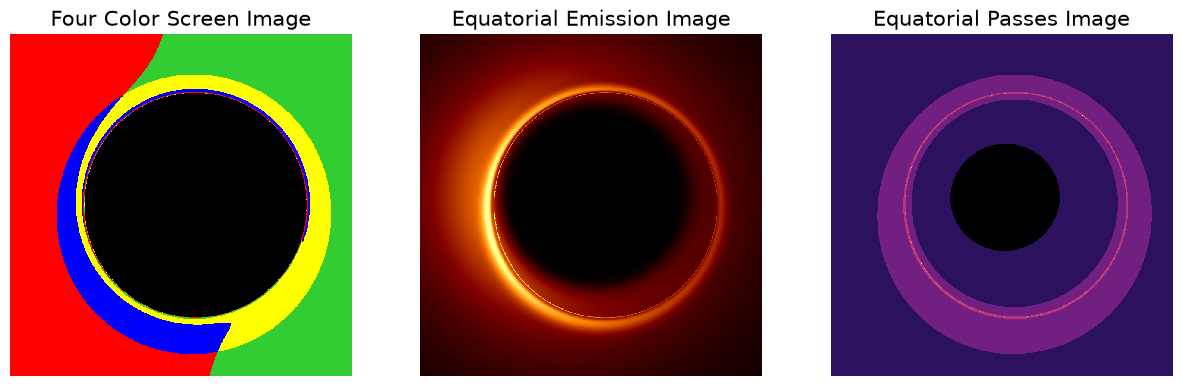

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

pf.FOORTToFourColorScreenImage("../FOORT/Output/KerrExample", NrFiles=2, Ax=ax[0])
pf.FOORTToEquatorialEmissionImage("../FOORT/Output/KerrExample", NrFiles=2, Ax=ax[1])
pf.FOORTToEquatorialPassesImage("../FOORT/Output/KerrExample", NrFiles=2, Ax=ax[2], 
                                DiagType="EquatorialEmission")

ax[0].set_title("Four Color Screen Image")
ax[1].set_title("Equatorial Emission Image")
ax[2].set_title("Equatorial Passes Image")

We can now also use the `PhotonRingInterferometry` package to visualize the visibility amplitudes (visamp) associated with the emission. The visamp calculation leverages the Radon transform and the projection-slice theorem: in practice, this means that the below function effectively calculates 1-dimensional slices of the 2-dimensional visamp.
Hence, we specify the angles at which we want to extract these slices.

The function allows the use to specify an angular size for the image (default is 50 $\mu\text{as}$), which appropriately returns the baselines in units of $\text{G}\lambda$.

In [43]:
visamps_Kerr, baselines_Kerr, _ = PRI.FOORTToVisAmp("../FOORT/Output/KerrExample", NrFiles=2, Angles = [40,60], Verbose=False)

Limiting data to range (0.0, 100000.0).
Max value after limiting: 0.580068


/Users/seppestaelens/miniconda3/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


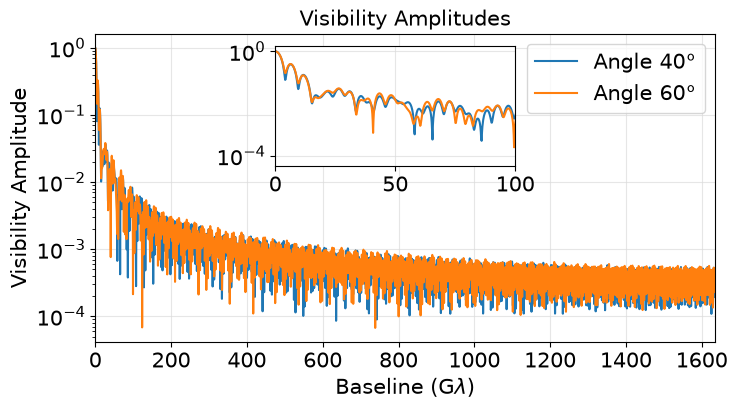

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

# plot visibility amplitudes for two angles
ax.plot(baselines_Kerr, visamps_Kerr[0], label="Angle 40°")
ax.plot(baselines_Kerr, visamps_Kerr[1], label="Angle 60°")

# axes
ax.set_xlim(left=0, right=np.max(baselines_Kerr))
ax.set_yscale("log")

# create an inset axes for zoomed-in view
axins = fig.add_axes([0.35, 0.55, 0.3, 0.3])  # [left, bottom, width, height]
axins.plot(baselines_Kerr, visamps_Kerr[0], label="Angle 40°")
axins.plot(baselines_Kerr, visamps_Kerr[1], label="Angle 60°")

# decorations
ax.legend()
ax.set_xlabel(r"Baseline (G$\lambda$)")
ax.set_ylabel("Visibility Amplitude")
ax.set_title("Visibility Amplitudes")
ax.grid(alpha=0.7, color='gainsboro')

axins.set_yscale("log")
axins.set_xlim(0, 100)  # zoom in on the first 100
axins.grid(alpha=0.7, color='gainsboro')

plt.show()

## Johannsen black hole

As an illustration, we repeat the above but for the Johannsen black hole. Again, a configuration file `JohannsenExample.cfg` should produce the output needed to run the below functions. For comparison, we also plot the Kerr results again.

Limiting data to range (0.0, 100000.0).
Max value after limiting: 0.535579
Limiting data to range (0.0, 100000.0).
Max value after limiting: 0.461866


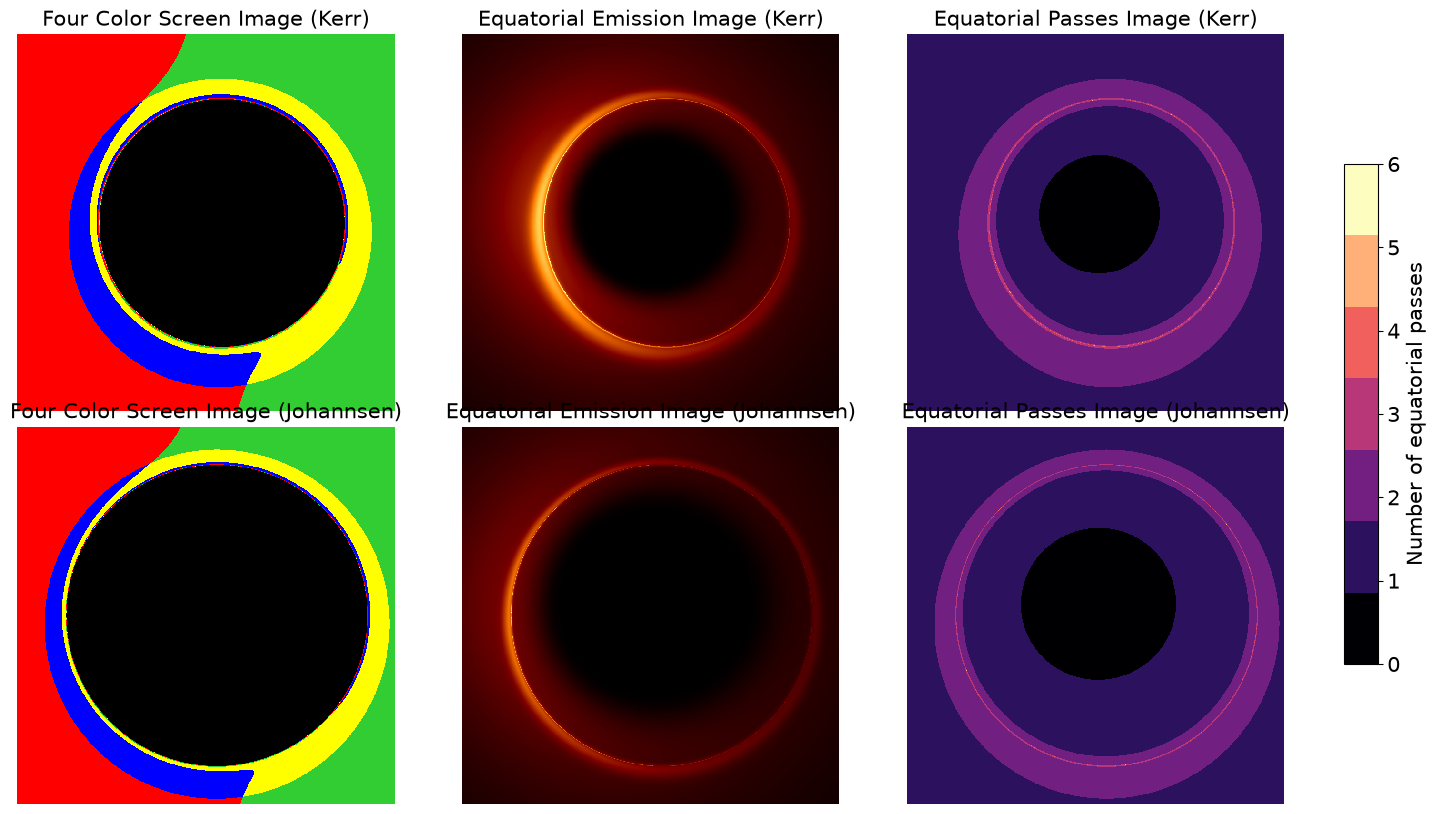

In [87]:
fig, ax = plt.subplots(2, 3, figsize=(17, 10))
fig.subplots_adjust(hspace=0.04, wspace=0.04)

pf.FOORTToFourColorScreenImage("../FOORT/Output/KerrExample", NrFiles=2, Ax=ax[0,0])
pf.FOORTToEquatorialEmissionImage("../FOORT/Output/KerrExample", NrFiles=2, Ax=ax[0,1])
pf.FOORTToEquatorialPassesImage("../FOORT/Output/KerrExample", NrFiles=2, Ax=ax[0,2], 
                                DiagType="EquatorialEmission")

pf.FOORTToFourColorScreenImage("../FOORT/Output/JohannsenExample", NrFiles=2, Ax=ax[1,0])
pf.FOORTToEquatorialEmissionImage("../FOORT/Output/JohannsenExample", NrFiles=2, Ax=ax[1,1])
pf.FOORTToEquatorialPassesImage("../FOORT/Output/JohannsenExample", NrFiles=2, Ax=ax[1,2], 
                                DiagType="EquatorialEmission")

ax[0,0].set_title("Four Color Screen Image (Kerr)")
ax[0,1].set_title("Equatorial Emission Image (Kerr)")
ax[0,2].set_title("Equatorial Passes Image (Kerr)")

ax[1,0].set_title("Four Color Screen Image (Johannsen)")
ax[1,1].set_title("Equatorial Emission Image (Johannsen)")
ax[1,2].set_title("Equatorial Passes Image (Johannsen)")

# add a colorbar to the right of the last column, based on ax[1,2]
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(ax[1,2].images[0], cax=cbar_ax)
cbar.set_label("Number of equatorial passes")

# fig.tight_layout()
# fig.savefig("Example_nb_images.png", dpi=300)
plt.show()

We have taken a rather high value of the coefficient $\alpha_{13}$ in the Johannsen metric, to make the difference in the above figures sufficiently apparent. Of course, taking this value closer to 0 makes the images look more and more alike. Give it a try!

Below, we compare the visibility amplitude against that of Kerr.

In [46]:
visamps_Joh, baselines_Joh, _ = PRI.FOORTToVisAmp("../FOORT/Output/JohannsenExample", NrFiles=2, Angles = [40,60], Verbose=False)

Limiting data to range (0.0, 100000.0).
Max value after limiting: 0.51285


/Users/seppestaelens/miniconda3/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


/var/folders/vq/_ms1s9j51m14tjk2yqc9vpbh0000gn/T/ipykernel_67426/2940759149.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


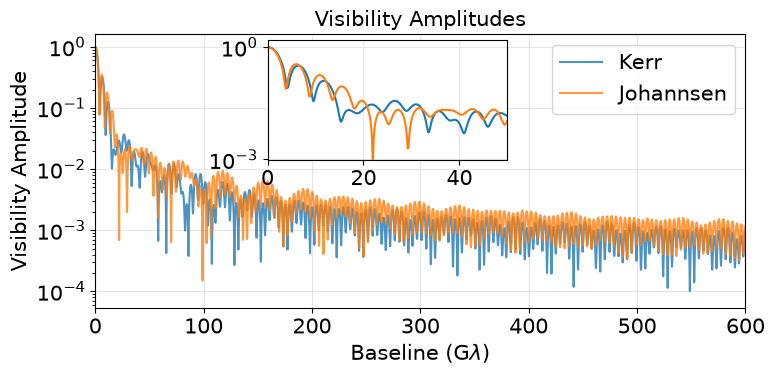

In [88]:
fig, ax = plt.subplots(figsize=(8, 4))

# plot visibility amplitudes for two angles
ax.plot(baselines_Kerr, visamps_Kerr[0], label="Kerr", alpha=0.8)
ax.plot(baselines_Joh, visamps_Joh[0], label="Johannsen", alpha=0.8)

# axes
ax.set_xlim(left=0, right=np.max(baselines_Joh))
ax.set_yscale("log")

# create an inset axes for zoomed-in view
axins = fig.add_axes([0.35, 0.57, 0.3, 0.3])  # [left, bottom, width, height]
axins.plot(baselines_Kerr, visamps_Kerr[0], label="Kerr")
axins.plot(baselines_Joh, visamps_Joh[0], label="Johannsen")

# decorations
ax.legend()
ax.set_xlabel(r"Baseline (G$\lambda$)")
ax.set_ylabel("Visibility Amplitude")
ax.set_title("Visibility Amplitudes")
ax.grid(alpha=0.7, color='gainsboro')
ax.set_xlim(0,600)

axins.set_yscale("log")
axins.set_xlim(0, 50)  # zoom in on the first 100
axins.set_ylim(bottom=1e-3)
axins.grid(alpha=0.7, color='gainsboro')

fig.tight_layout()
# fig.savefig("Example_nb_visamps.png", dpi=300)
plt.show()